# 🔬 U-Net Classifier - Plant Disease Classification

**Model:** U-Net Encoder adapted for Classification

**Architecture:**
- U-Net encoder (ResNet50 backbone)
- Global Average Pooling
- Classification head

**Why U-Net for Classification:**
- U-Net excels at feature extraction
- Encoder captures hierarchical features
- Pre-trained encoders available

**Configuration:**
- ResNet50 encoder with ImageNet weights
- 224x224 images
- 15 epochs with early stopping

---

## ⚠️ Enable GPU: Runtime → Change runtime type → T4 GPU

In [1]:
import torch
print(f"GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

GPU: True
Device: Tesla T4


In [2]:
!pip install -q segmentation-models-pytorch timm albumentations scikit-learn opendatasets
print("✅ Installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.2 MB/s eta 0:00:00
✅ Installed


In [3]:
import os, opendatasets as od
if not os.path.exists('/content/plantvillage'):
    od.download("https://www.kaggle.com/datasets/mohitsingh1804/plantvillage")
if not os.path.exists('/content/PlantDoc-Dataset'):
    !git clone https://github.com/pratikkayal/PlantDoc-Dataset.git
print("✅ Datasets ready")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mohinarustamova
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage


100%|██████████| 818M/818M [00:03<00:00, 215MB/s] 



Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 37.49 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.
✅ Datasets ready


In [15]:
import os, random, numpy as np, pandas as pd, cv2, json, time, warnings
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

pv_base = Path('/content/plantvillage/PlantVillage') if Path('/content/plantvillage/PlantVillage').exists() else Path('/content/plantvillage')
PV_TRAIN, PV_VAL, PD_TEST = pv_base/'train', pv_base/'val', Path('/content/PlantDoc-Dataset/test')

BATCH_SIZE, EPOCHS, LR, IMG_SIZE = 32, 10, 1e-4, 224
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
random.seed(42); np.random.seed(42); torch.manual_seed(42)

In [16]:
common_labels = sorted([
    "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
    "Blueberry___healthy", "Cherry_(including_sour)___healthy", "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight", "Grape___healthy", "Peach___healthy",
    "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy", "Potato___Early_blight",
    "Potato___Late_blight", "Potato___healthy", "Raspberry___healthy", "Soybean___healthy",
    "Squash___Powdery_mildew", "Strawberry___Leaf_scorch", "Strawberry___healthy",
    "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight",
    "Tomato___Leaf_Mold", "Tomato___Septoria_leaf_spot", "Tomato___Spider_mites_Two-spotted_spider_mite",
    "Tomato___Target_Spot", "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus", "Tomato___healthy"
])

plantdoc_to_plantvillage = {
    "Apple leaf": "Apple___healthy", "Apple rust leaf": "Apple___Cedar_apple_rust",
    "Apple Scab Leaf": "Apple___Apple_scab", "Bell_pepper leaf": "Pepper,_bell___healthy",
    "Bell_pepper leaf spot": "Pepper,_bell___Bacterial_spot", "Blueberry leaf": "Blueberry___healthy",
    "Cherry leaf": "Cherry_(including_sour)___healthy", "Corn Gray leaf spot": "Corn_(maize)___Northern_Leaf_Blight",
    "Corn leaf blight": "Corn_(maize)___Northern_Leaf_Blight", "Corn rust leaf": "Corn_(maize)___Common_rust_",
    "Peach leaf": "Peach___healthy", "Potato leaf": "Potato___healthy",
    "Potato leaf early blight": "Potato___Early_blight", "Potato leaf late blight": "Potato___Late_blight",
    "Raspberry leaf": "Raspberry___healthy", "Soybean leaf": "Soybean___healthy",
    "Squash Powdery mildew leaf": "Squash___Powdery_mildew", "Strawberry leaf": "Strawberry___healthy",
    "Tomato Early blight leaf": "Tomato___Early_blight", "Tomato Septoria leaf spot": "Tomato___Septoria_leaf_spot",
    "Tomato leaf": "Tomato___healthy", "Tomato leaf bacterial spot": "Tomato___Bacterial_spot",
    "Tomato leaf late blight": "Tomato___Late_blight", "Tomato leaf mosaic virus": "Tomato___Tomato_mosaic_virus",
    "Tomato leaf yellow virus": "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato mold leaf": "Tomato___Leaf_Mold",
    "Tomato two spotted spider mites leaf": "Tomato___Spider_mites_Two-spotted_spider_mite",
    "grape leaf": "Grape___healthy", "grape leaf black rot": "Apple___Black_rot"
}

label2idx = {l: i for i, l in enumerate(common_labels)}
num_classes = len(common_labels)
print(f"Classes: {num_classes}")

Classes: 30


In [17]:
# U-Net Classifier Architecture
class UNetClassifier(nn.Module):
    """U-Net encoder adapted for classification"""
    def __init__(self, encoder_name='resnet50', num_classes=30):
        super().__init__()
        # Create U-Net but we'll only use the encoder
        unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights='imagenet',
            in_channels=3,
            classes=1  # Dummy, we won't use decoder
        )

        # Extract encoder only
        self.encoder = unet.encoder

        # Get encoder output channels
        # For ResNet50: [3, 64, 256, 512, 1024, 2048]
        encoder_channels = unet.encoder.out_channels[-1]  # 2048 for ResNet50

        # Classification head
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(encoder_channels, num_classes)

    def forward(self, x):
        # Get encoder features
        features = self.encoder(x)

        # Use the deepest features
        x = features[-1]

        # Global pooling
        x = self.pool(x)
        x = torch.flatten(x, 1)

        # Classifier
        x = self.dropout(x)
        x = self.fc(x)

        return x

print("✅ U-Net Classifier architecture defined")

✅ U-Net Classifier architecture defined


In [18]:
class Augmentation:
    def __init__(self, img_size=224, is_train=False):
        if is_train:
            self.t = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
                ToTensorV2()
            ])
        else:
            self.t = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
                ToTensorV2()
            ])
    def __call__(self, img):
        return self.t(image=np.array(img) if isinstance(img, Image.Image) else img)['image']

class PVDataset(Dataset):
    def __init__(self, root, l2i, size=224, is_train=False):
        self.t = Augmentation(size, is_train)
        self.samples = [(str(p), l2i[l]) for l in l2i for ext in ['*.jpg','*.JPG','*.png']
                       for p in (Path(root)/l).glob(ext) if (Path(root)/l).exists()]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        return self.t(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)), l

class PDDataset(Dataset):
    def __init__(self, root, l2i, pd2pv, size=224):
        self.t = Augmentation(size, is_train=False)
        self.samples = [(str(p), l2i[pv]) for pd, pv in pd2pv.items() if pv in l2i
                       for ext in ['*.jpg','*.JPG','*.png'] for p in (Path(root)/pd).glob(ext)
                       if (Path(root)/pd).exists()]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        return self.t(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)), l

In [19]:
trn = PVDataset(str(PV_TRAIN), label2idx, IMG_SIZE, is_train=True)
val = PVDataset(str(PV_VAL), label2idx, IMG_SIZE, is_train=False)
tst = PDDataset(str(PD_TEST), label2idx, plantdoc_to_plantvillage, IMG_SIZE)

trn_l = DataLoader(trn, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_l = DataLoader(val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
tst_l = DataLoader(tst, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(trn):,} | Val: {len(val):,} | Test: {len(tst):,}")

Train: 30,766 | Val: 7,692 | Test: 228


In [20]:
print("Loading U-Net Classifier (ResNet50 encoder)...")
model = UNetClassifier(encoder_name='resnet50', num_classes=num_classes)
model = model.to(DEVICE)
print(f"✅ Model loaded on {DEVICE}")

Loading U-Net Classifier (ResNet50 encoder)...
✅ Model loaded on cuda


In [21]:
def train_epoch(m, loader, crit, opt, dev):
    m.train(); loss_sum, corr, tot = 0, 0, 0
    for img, lbl in tqdm(loader, desc='Train', leave=False):
        img, lbl = img.to(dev), lbl.to(dev)
        opt.zero_grad(); out = m(img); loss = crit(out, lbl)
        loss.backward(); opt.step()
        loss_sum += loss.item(); tot += lbl.size(0)
        corr += out.max(1)[1].eq(lbl).sum().item()
    return loss_sum/len(loader), 100.*corr/tot

def evaluate(m, loader, crit, dev):
    m.eval(); loss_sum, preds, labels = 0, [], []
    with torch.no_grad():
        for img, lbl in tqdm(loader, desc='Eval', leave=False):
            img, lbl = img.to(dev), lbl.to(dev)
            out = m(img); loss_sum += crit(out, lbl).item()
            preds.extend(out.max(1)[1].cpu().numpy())
            labels.extend(lbl.cpu().numpy())
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    return {'loss': loss_sum/len(loader), 'acc': acc*100, 'f1': f1*100, 'precision': p*100, 'recall': r*100}

In [22]:
print("\n" + "="*60)
print("Training U-Net Classifier")
print("="*60 + "\n")

crit = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)

best_f1, patience_counter = 0, 0
t0 = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    tl, ta = train_epoch(model, trn_l, crit, opt, DEVICE)
    v = evaluate(model, val_l, crit, DEVICE)
    sch.step(v['f1'])

    print(f"Loss: {tl:.4f} | Train Acc: {ta:.2f}% | Val F1: {v['f1']:.2f}%")

    if v['f1'] > best_f1:
        best_f1 = v['f1']; patience_counter = 0
        torch.save(model.state_dict(), '/content/unet_classifier_best.pth')
        print(f"✓ Best F1: {best_f1:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print(f"Early stop"); break

model.load_state_dict(torch.load('/content/unet_classifier_best.pth'))
test = evaluate(model, tst_l, crit, DEVICE)
training_time = time.time() - t0

print(f"\n{'='*60}")
print("FINAL RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test['acc']:.2f}%")
print(f"Test F1: {test['f1']:.2f}%")
print(f"Test Precision: {test['precision']:.2f}%")
print(f"Test Recall: {test['recall']:.2f}%")
print(f"Training Time: {training_time/60:.1f} min")
print(f"{'='*60}")


Training U-Net Classifier


Epoch 1/10


Train:   0%|          | 0/962 [00:00<?, ?it/s]

Eval:   0%|          | 0/241 [00:00<?, ?it/s]

Loss: 0.2362 | Train Acc: 93.96% | Val F1: 99.09%
✓ Best F1: 99.09%

Epoch 2/10


Train:   0%|          | 0/962 [00:00<?, ?it/s]

...

Train:   0%|          | 0/962 [00:00<?, ?it/s]

Eval:   0%|          | 0/241 [00:00<?, ?it/s]

Loss: 0.0051 | Train Acc: 99.86% | Val F1: 99.91%
✓ Best F1: 99.91%


Eval:   0%|          | 0/8 [00:00<?, ?it/s]


FINAL RESULTS
Test Accuracy: 25.00%
Test F1: 23.24%
Test Precision: 30.03%
Test Recall: 25.00%
Training Time: 66.9 min


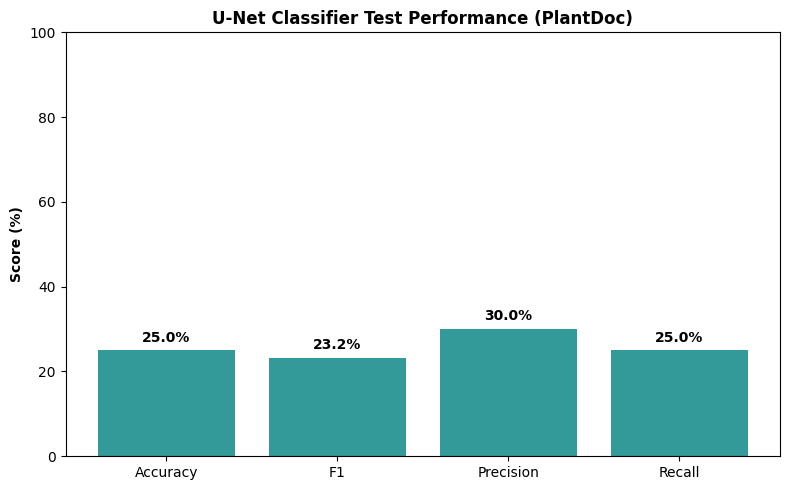


✅ Saved: unet_classifier_best.pth, unet_classifier_results.json, unet_classifier_results.png


In [23]:
results = {
    'model': 'U-Net Classifier (ResNet50 Encoder)',
    'encoder': 'resnet50',
    'test_acc': test['acc'],
    'test_f1': test['f1'],
    'test_precision': test['precision'],
    'test_recall': test['recall'],
    'best_val_f1': best_f1,
    'time_minutes': training_time/60
}

with open('/content/unet_classifier_results.json', 'w') as f:
    json.dump(results, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
values = [test['acc'], test['f1'], test['precision'], test['recall']]
ax.bar(metrics, values, color='teal', alpha=0.8)
ax.set_ylabel('Score (%)', fontweight='bold')
ax.set_title('U-Net Classifier Test Performance (PlantDoc)', fontweight='bold')
ax.set_ylim([0, 100])
for i, v in enumerate(values):
    ax.text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/unet_classifier_results.png', dpi=300)
plt.show()

print("\n✅ Saved: unet_classifier_best.pth, unet_classifier_results.json, unet_classifier_results.png")

In [24]:
from google.colab import files
files.download('/content/unet_classifier_results.json')
files.download('/content/unet_classifier_results.png')
print("✅ Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!
